# Joint Fairness-Diversity Score (JFDS)
### From Four EDAs and Five Papers to a New Re-Ranking Equation

**Research Process:**
>We first explored four real world recommendation datasets through exploratory data analysis. We then compared our findings with insights from five key research papers. Based on this, we developed a new ranking method called the **Joint Fairness Diversity Score (JFDS)**. It balances recommendation quality, item fairness, and diversity using a simple greedy selection approach.



---
## Four Exploratory Data Analyses
---

Before touching any model, we ran structured EDAs on four distinct datasets to look for **consistent, cross-domain patterns** in how recommendation systems handle popularity, fairness, and diversity.

| Dataset | Domain | Scale |
|---|---|---|
| **MovieLens 1M** | Movie ratings | 1 M ratings · 3,883 movies · 6,040 users |
| **Amazon Beauty** | Product reviews | 1.35 M ratings · 23,838 products · 883 k users |
| **Goodreads Books** | Book catalogue | 199 M ratings · 11,123 books · 6,639 authors |
| **Last.fm Scrobbles** | Music listening | 166 k plays · 76 k tracks · 22 k artists |

---

### EDA Finding 1: Popularity Bias Is Common Across All Datasets

The first pattern we found was the same in every dataset. A small number of items received most of the user interactions.

| Dataset         | Popular items (top 20%) | Share of total interactions |
| --------------- | ----------------------- | --------------------------- |
| MovieLens 1M    | 743 movies              | **65.2%** of all ratings    |
| Amazon Beauty   | 4,831 products          | **57.6%** of all ratings    |
| Goodreads Books | 2,225 books             | **94.7%** of all ratings    |
| Last.fm         | 16,319 tracks           | **55.3%** of all plays      |

In MovieLens, the least popular half of the catalogue received only **0.1%** of all ratings. We observed a similar pattern in the other datasets. This shows that user interactions are heavily concentrated on a small number of popular items.

**Implication:** A recommender system that focuses only on improving accuracy is likely to recommend these popular items more often while ignoring less popular ones. This leads to the well known problem of popularity bias.


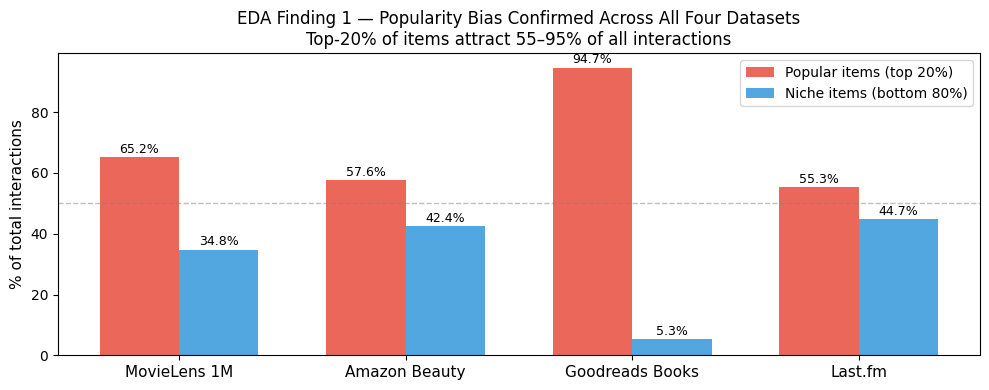

Figure saved ✓


In [1]:
# Observed from EDA — popularity shares across datasets
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

datasets = {
    'MovieLens 1M'   : {'pop_share': 65.2, 'niche_share': 34.8, 'n_ratings': '1.0M',  'n_items': 3883},
    'Amazon Beauty'  : {'pop_share': 57.6, 'niche_share': 42.4, 'n_ratings': '1.35M', 'n_items': 23838},
    'Goodreads Books': {'pop_share': 94.7, 'niche_share':  5.3, 'n_ratings': '199M',  'n_items': 11123},
    'Last.fm'        : {'pop_share': 55.3, 'niche_share': 44.7, 'n_ratings': '166k',  'n_items': 76038},
}

df_pop = pd.DataFrame(datasets).T.reset_index().rename(columns={'index':'Dataset'})

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_pop))
w = 0.35
ax.bar(x - w/2, df_pop['pop_share'],   w, label='Popular items (top 20%)',    color='#E74C3C', alpha=0.85)
ax.bar(x + w/2, df_pop['niche_share'], w, label='Niche items (bottom 80%)',   color='#3498DB', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_pop['Dataset'], fontsize=11)
ax.set_ylabel('% of total interactions', fontsize=11)
ax.set_title('EDA Finding 1 — Popularity Bias Confirmed Across All Four Datasets\n'
             'Top-20% of items attract 55–95% of all interactions', fontsize=12)
ax.legend(fontsize=10)
ax.axhline(50, color='grey', linestyle='--', lw=1, alpha=0.5, label='50% line')
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('eda_finding1_popularity_bias.png', dpi=110, bbox_inches='tight')
plt.show()
print("Figure saved ✓")


---

### EDA Finding 2 - Popularity Is Not the Same as Quality

Here we ask a simple question: *Are popular items popular because they are actually better?*

To check this, we compare the average quality of popular items and niche items.

The table below shows the average rating or quality score for both groups:

| Dataset | Popular items | Niche items | Difference |
|---|---:|---:|---|
| MovieLens 1M (avg rating) | 3.75 | 3.27 | Popular higher by 0.48 |
| Amazon Beauty (avg rating) | 4.14 | 4.15 | Almost no difference |
| Goodreads Books (avg rating) | 3.98 | 3.92 | Very small difference |
| Last.fm (repeat plays/user) | 1.46 | 1.06 | Popular higher by 0.40 |

This table shows that the difference is not the same for every dataset. In **Amazon Beauty**, there is almost no difference. In **Goodreads Books**, the difference is very small. This means many niche items can be just as good as popular items, even if fewer people see them.

For **MovieLens** and **Last.fm**, popular items do score higher. But this still does not mean popularity is only about quality. Popular items also get more attention, more clicks, and more recommendations, which can make them even more popular over time.

**Implication:** A recommender system should not recommend only popular items. Some niche items are also good, but they get ignored because they have less exposure. This creates unfairness for niche items.


---

### EDA Finding 3 - More Niche Items Means More Variety

Here we check what happens when we add more niche items into recommendation lists.

We changed the recommendation lists from mostly popular items to more niche items. Then we counted how many different items appeared overall.

The table below shows the relationship between niche items and variety. A value close to `1` means a strong positive relationship:

| Dataset | Relationship between niche items and variety |
|---|---|
| MovieLens 1M   | **r = 0.893** |
| Amazon Beauty  | **r = 0.911** |
| Last.fm        | **r = 0.880** |
| Goodreads Books | **r = 0.909** |

All values are close to `1`, so the pattern is strong in every dataset.

This happens because popular items are often repeated for many users. For example, many users may get the same popular movie, product, book, or artist. Niche items are more spread out, so adding niche items usually adds new items to the overall recommendation system.

**Simple meaning:** Showing more niche items makes the system fairer and also gives users more variety. So fairness and variety improve together.


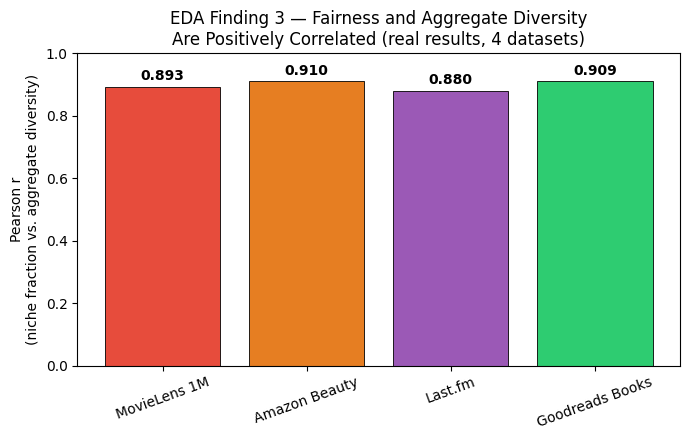

Real Pearson r values used above (no simulation):
  MovieLens 1M       r = 0.8926
  Amazon Beauty      r = 0.9105
  Last.fm            r = 0.8803
  Goodreads Books    r = 0.9093


In [ ]:
import matplotlib.pyplot as plt

real_r = {
    'MovieLens 1M'    : 0.8926,
    'Amazon Beauty'   : 0.9105,
    'Last.fm'         : 0.8803,
    'Goodreads Books' : 0.9093,
}

fig, ax = plt.subplots(figsize=(7, 4.5))

colors = ['#E74C3C', '#E67E22', '#9B59B6', '#2ECC71']
bars = ax.bar(real_r.keys(), real_r.values(), color=colors, edgecolor='black', linewidth=0.6)
ax.set_ylim(0, 1)
ax.set_ylabel('Pearson r\n(niche fraction vs. aggregate diversity)')
ax.set_title('EDA Finding 3 — Fairness and Aggregate Diversity\nAre Positively Correlated (real results, 4 datasets)')
ax.tick_params(axis='x', rotation=20)
for b, v in zip(bars, real_r.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Real Pearson r values used above (no simulation):')
for k, v in real_r.items():
    print(f'  {k:<18s} r = {v:.4f}')

---

### EDA Finding 4 - Fairness Can Sometimes Reduce Variety Inside One List

This finding shows an important problem. Showing more niche items can improve fairness, but it does not always make each user's recommendation list more varied.

To check this, we measured how similar popular items are to each other, and how similar niche items are to each other.

| Dataset | Similarity between popular items | Similarity between niche items |
|---|---|---|
| MovieLens 1M (genre cosine) | 0.220 | **0.214** (higher zero-sim: 70.6% vs 60.5%) |
| Amazon Beauty (product-type) | 0.134 | 0.118 |
| Last.fm (co-listening) | **0.488** | 0.246 |

In **MovieLens**, some niche movies are grouped more closely by genre. This means the niche tail is not always spread evenly across all genres. Some underexposed genres contain many niche items.

In **Last.fm**, many niche tracks are connected to only one listener. So even if a list contains many niche tracks, those tracks may still come from one narrow music taste.

**Implication:** Fairness and individual list diversity are not the same thing. If we only boost niche items, the recommendation list may still contain items that are too similar to each other. So the re-ranking score needs a separate **diversity term**.

This is why the JFDS equation includes both fairness and diversity.


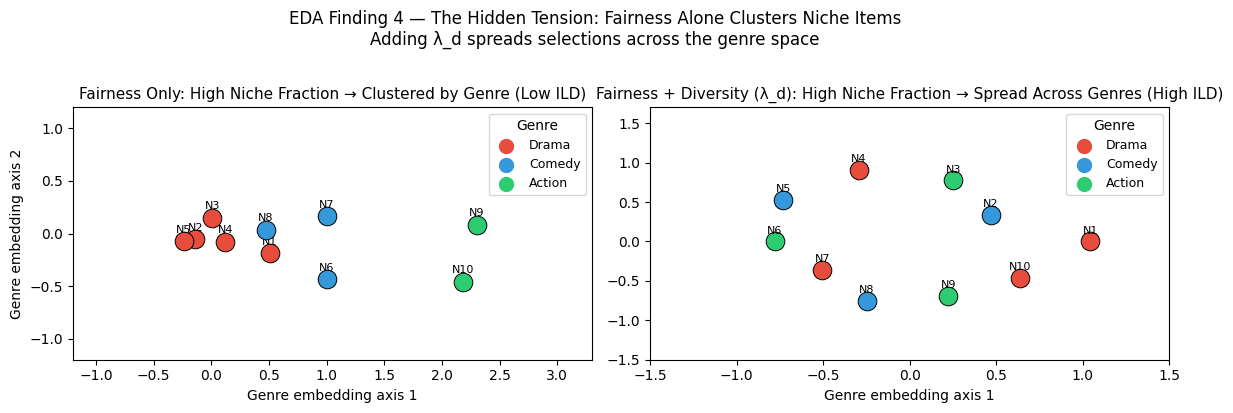

Figure saved ✓


In [6]:
# Visualise the fairness-ILD tension conceptually
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LEFT: fair-only re-ranking (high niche fraction, but grouped by genre)
np.random.seed(7)
genres_niche = np.array([0]*5 + [1]*3 + [2]*2)  # 5 drama, 3 comedy, 2 action
x_niche = np.random.randn(10) * 0.3 + genres_niche
y_niche = np.random.randn(10) * 0.3
colors_niche = ['#E74C3C','#3498DB','#2ECC71']
for i, (xv, yv, g) in enumerate(zip(x_niche, y_niche, genres_niche)):
    axes[0].scatter(xv, yv, s=180, c=colors_niche[g], edgecolors='k', linewidths=0.7, zorder=3)
    axes[0].text(xv, yv+0.08, f'N{i+1}', ha='center', fontsize=8)
axes[0].set_title('Fairness Only: High Niche Fraction → Clustered by Genre (Low ILD)', fontsize=11)
axes[0].set_xlim(-1.2, 3.3)
axes[0].set_ylim(-1.2, 1.2)
axes[0].set_xlabel('Genre embedding axis 1')
axes[0].set_ylabel('Genre embedding axis 2')
for g, label, c in [(0,'Drama','#E74C3C'),(1,'Comedy','#3498DB'),(2,'Action','#2ECC71')]:
    axes[0].scatter([], [], c=c, s=100, label=label)
axes[0].legend(title='Genre', fontsize=9)

# RIGHT: fairness + diversity (items spread across genre space)
angles = np.linspace(0, 2*np.pi, 11)[:-1]
r_vals = np.random.uniform(0.5, 1.1, 10)
x_div = r_vals * np.cos(angles)
y_div = r_vals * np.sin(angles)
genre_div = [0,1,2,0,1,2,0,1,2,0]
for i, (xv, yv, g) in enumerate(zip(x_div, y_div, genre_div)):
    axes[1].scatter(xv, yv, s=180, c=colors_niche[g], edgecolors='k', linewidths=0.7, zorder=3)
    axes[1].text(xv, yv+0.1, f'N{i+1}', ha='center', fontsize=8)
axes[1].set_title('Fairness + Diversity (λ_d): High Niche Fraction → Spread Across Genres (High ILD)', fontsize=11)
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.7)
axes[1].set_xlabel('Genre embedding axis 1')
for g, label, c in [(0,'Drama','#E74C3C'),(1,'Comedy','#3498DB'),(2,'Action','#2ECC71')]:
    axes[1].scatter([], [], c=c, s=100, label=label)
axes[1].legend(title='Genre', fontsize=9)

plt.suptitle('EDA Finding 4 — The Hidden Tension: Fairness Alone Clusters Niche Items\n'
             'Adding λ_d spreads selections across the genre space',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('eda_finding4_tension.png', dpi=110, bbox_inches='tight')
plt.show()
print("Figure saved ✓")


---
## Five Foundational Papers

With these four EDA findings in hand, we turned to the literature to understand what theoretical frameworks already existed, and where the gap was.


---

### Paper 1 – Carbonell & Goldstein (1998): Maximal Marginal Relevance (MMR)

**Carbonell, J. & Goldstein, J. (1998).** *The Use of MMR, Diversity-Based Reranking for Reordering Documents and Producing Summaries.* SIGIR.

This paper introduced **Maximal Marginal Relevance (MMR)**, a method for selecting items one at a time while balancing **relevance** and **diversity**. Instead of choosing only the most relevant item at each step, MMR also considers how similar that item is to the items that have already been selected. This helps reduce redundancy and produces a more diverse final recommendation list.

The MMR equation is

$$
\text{MMR}=\arg\max_{D_i\in R\setminus S}
\left[
\lambda \cdot \text{Sim}_1(D_i,Q)
-
(1-\lambda)\cdot
\max_{D_j\in S}\text{Sim}_2(D_i,D_j)
\right]
$$

Before understanding the equation, each symbol is explained below.

- **$Q$**: The user's query or information need. In a movie recommender system, this represents the user's preferences or profile.

- **$R$**: The set of all candidate items retrieved for the query. These are the movies available to be recommended.

- **$S$**: The set of items that have already been selected. Initially, this set is empty. As recommendations are chosen one by one, each selected movie is added to $S$.

- **$R \setminus S$**: The set of candidate items that have **not yet been selected**. At every iteration, MMR only evaluates movies from this set.

- **$D_i$**: The candidate item currently being evaluated. In our recommender system, this is one candidate movie.

- **$D_j$**: A movie that has already been selected and is contained in the set $S$.

- **$\text{Sim}_1(D_i,Q)$**: The similarity between the candidate movie and the user's query. This measures how relevant the candidate movie is to the user's preferences.

- **$\text{Sim}_2(D_i,D_j)$**: The similarity between the candidate movie and a previously selected movie. This measures how similar the two movies are.

- **$\lambda$**: A weighting parameter between 0 and 1 that controls the balance between relevance and diversity.
  - A larger value of $\lambda$ gives more importance to relevance.
  - A smaller value of $\lambda$ gives more importance to diversity.

- **$\arg\max$**: This means **select the candidate with the highest score**. After calculating the MMR score for every candidate movie, the one with the largest score is added to the recommendation list.

---

### How MMR Works

MMR builds the recommendation list one movie at a time.

1. Initially, the selected set is empty:

   $$
   S=\emptyset
   $$

2. The first movie is selected based only on relevance because there are no previously selected movies.

3. After the first movie is selected, it is added to the selected set:

   $$
   S=\{\text{Movie}_1\}
   $$

4. For every remaining candidate movie, MMR calculates:
   - how relevant the movie is to the user's preferences, and
   - how similar it is to the movies already contained in $S$.

5. The movie with the highest MMR score is selected and added to $S$.

6. This process repeats until the desired number of recommendations has been generated.

In simple words, MMR follows the idea:

> Select a movie that is highly relevant to the user, but avoid recommending another movie that is almost the same as one already selected.

This is how MMR reduces redundancy in the recommendation list.

---

### Understanding the Diversity Component

The diversity part of the MMR equation is

$$
\max_{D_j\in S}\text{Sim}_2(D_i,D_j)
$$

This term measures **how similar the candidate movie is to the movies that have already been selected**.

To understand this expression, consider each part separately.

- **$D_i$** is the candidate movie currently being evaluated.
- **$S$** is the set of movies that have already been selected.
- **$D_j$** represents one movie inside the selected set $S$.
- **$\text{Sim}_2(D_i,D_j)$** calculates the similarity between the candidate movie and one selected movie.

Suppose the selected set is

$$
S=
\{
\text{Interstellar},
\text{Gravity},
\text{Arrival}
\}
$$

and the candidate movie is **The Martian**.

The similarity scores are

- Similarity with **Interstellar** = 0.93
- Similarity with **Gravity** = 0.62
- Similarity with **Arrival** = 0.40

The **max** operator chooses only the largest similarity value:

$$
\max(0.93,\;0.62,\;0.40)=0.93
$$

Notice that MMR ignores the other similarity values. It only keeps the similarity to the **closest previously selected movie**.

If the candidate movie is very similar to even one movie already in the recommendation list, it receives a large redundancy penalty.

---

### How This Connects to Our JFDS Equation

Our JFDS model follows the same main idea as MMR: a candidate movie should be **relevant** while also adding **diversity** to the recommendation list.

However, instead of using only the maximum similarity, our model measures diversity using

$$
div(i,S)
=
\frac{1}{|S|}
\sum_{j\in S}
\left(1-\cos(g_i,g_j)\right)
$$

Before understanding this equation, each symbol is explained below.

- **$i$**: The candidate movie currently being evaluated.

- **$S$**: The set of movies that have already been selected.

- **$|S|$**: The number of movies in the selected set.

- **$g_i$**: The genre vector of the candidate movie.

- **$g_j$**: The genre vector of a previously selected movie.

- **$\cos(g_i,g_j)$**: The cosine similarity between the genre vectors of the candidate movie and one selected movie.

- **$1-\cos(g_i,g_j)$**: The cosine distance between the two genre vectors. A larger value means the movies are more different.

- **$\sum_{j\in S}$**: Compute the cosine distance between the candidate movie and **every** movie already in the selected set, then add all those distances together.

- **$\frac{1}{|S|}$**: Divide the total distance by the number of selected movies. This calculates the **average cosine distance**.

Therefore, $div(i,S)$ measures

> **How different the candidate movie is, on average, from all movies that have already been selected.**

Unlike MMR, which only compares the candidate movie with its **single most similar** selected movie, our method compares it with **every selected movie**.

For example, suppose

$$
S=
\{
\text{Interstellar},
\text{Toy Story},
\text{Titanic}
\}
$$

and the candidate movie is **The Martian**.

Assume the cosine similarities are

| Selected Movie | Cosine Similarity | Cosine Distance |
|----------------|------------------:|----------------:|
| Interstellar | 0.90 | 0.10 |
| Toy Story | 0.20 | 0.80 |
| Titanic | 0.35 | 0.65 |

The diversity score becomes

$$
div(i,S)
=
\frac{0.10+0.80+0.65}{3}
=
0.5167
$$

This means that, **on average**, the candidate movie is moderately different from the movies already in the recommendation list.

---

### Difference Between MMR and Our JFDS Diversity

The key difference is how diversity is measured.

**MMR**

- Computes the similarity between the candidate movie and every selected movie.
- Keeps **only the largest similarity**.
- Penalizes the candidate based on its closest previously selected movie.

**Our JFDS**

- Computes the cosine distance between the candidate movie and every selected movie.
- Averages all the distances.
- Measures how different the candidate movie is from the **entire recommendation list**, not just one movie.

Using the average cosine distance provides a smoother and more stable diversity score because every selected movie contributes to the calculation. As a result, the recommendation list becomes more balanced across genres while still maintaining relevance.

---
# **END**
---

### Paper 2 – Steck (2018): Calibrated Recommendations

**Steck, H. (2018).** *Calibrated Recommendations.* RecSys.

This paper introduced the concept of **calibrated recommendations**, which aims to ensure that the recommended list reflects a user's interests in the **same proportions** as their historical preferences. Traditional recommender systems usually optimise only for prediction accuracy. As a result, they tend to over-recommend a user's dominant interests while ignoring their less frequent preferences.

For example, suppose a user's watching history consists of:

- 70% Romance
- 30% Action

An accuracy-optimised recommender may produce recommendations that are almost entirely Romance movies because Romance receives higher predicted relevance scores. Consequently, the user's smaller interest in Action movies is crowded out, even though it is still an important part of their preferences.

Steck formulated calibration as a **re-ranking optimization problem**, where the final recommendation list should balance recommendation accuracy with how closely its genre distribution matches the user's historical genre distribution.

The optimization objective is

$$
I^*
=
\arg\max_{I,\ |I|=N}
\left[
(1-\lambda)\cdot s(I)
-
\lambda\cdot C_{KL}(p,q(I))
\right]
$$

Before understanding the equation, each symbol is explained below.

- **$I$**: A candidate recommendation list.

- **$I^*$**: The optimal recommendation list selected after calibration.

- **$|I|=N$**: The recommendation list contains exactly **$N$** items.

- **$s(I)$**: The overall relevance (or recommendation score) of the recommendation list. Larger values indicate a more accurate recommendation list.

- **$p(g|u)$**: The user's historical genre distribution. It represents how frequently user **$u$** has interacted with each genre **$g$** in the past.

- **$q(g|u)$** (written as $q(I)$ in the equation): The genre distribution of the recommended list.

- **$C_{KL}(p,q(I))$**: The **Kullback-Leibler (KL) divergence** between the user's historical genre distribution and the recommendation genre distribution. It measures how different the two distributions are.

- **$\lambda$**: A weighting parameter between 0 and 1 that controls the trade-off between recommendation accuracy and calibration.
  - A larger value of $\lambda$ gives more importance to calibration.
  - A smaller value of $\lambda$ gives more importance to recommendation accuracy.

- **$\arg\max$**: This means **select the recommendation list with the highest overall objective value**.

---

### Understanding the Two Genre Distributions

The calibration objective compares two probability distributions.

#### 1. User Preference Distribution: $p(g|u)$

This distribution represents the user's historical interests.

For example, if a user has watched

| Genre | Percentage |
|--------|-----------:|
| Romance | 70% |
| Action | 30% |

then

$$
p(g|u)
=
[0.70,\ 0.30]
$$

This is considered the target distribution because it reflects the user's actual interests.

---

#### 2. Recommendation Distribution: $q(g|u)$

This distribution represents the genres present in the recommended list.

Suppose the recommender returns

| Genre | Percentage |
|--------|-----------:|
| Romance | 100% |
| Action | 0% |

Then

$$
q(g|u)
=
[1.00,\ 0.00]
$$

Although these recommendations may have high predicted relevance, they do not accurately reflect the user's overall interests.

---

### What is KL Divergence?

The calibration term in the objective function is

$$
C_{KL}(p,q(I))
$$

This is the **Kullback-Leibler (KL) divergence**, a statistical measure that calculates the difference between two probability distributions.

In this paper,

- **$p(g|u)$** is the user's historical genre distribution.
- **$q(g|u)$** is the genre distribution of the recommended list.

The KL divergence measures **how far the recommendation distribution is from the user's true preference distribution**.

- A **small KL divergence** means the recommendations closely match the user's interests.
- A **large KL divergence** means the recommendations are poorly calibrated and overrepresent some genres while underrepresenting others.

Therefore, minimizing KL divergence produces recommendations that better reflect the user's complete range of interests.

---

### How the Calibration Objective Works

The objective function contains two competing terms.

#### First Term

$$
(1-\lambda)\cdot s(I)
$$

This rewards recommendation lists that have high relevance and prediction accuracy.

---

#### Second Term

$$
\lambda\cdot C_{KL}(p,q(I))
$$

This penalizes recommendation lists whose genre distribution differs from the user's historical genre distribution.

---

The recommender therefore tries to

- maximize recommendation relevance, while
- minimizing the difference between the user's historical interests and the recommended genres.

This creates a balanced recommendation list that is both accurate and representative of the user's preferences.

---

### Experimental Findings

Steck evaluated the calibration approach using the **MovieLens 20M** dataset.

The experiments showed that increasing the calibration weight significantly improved genre calibration while causing only a relatively small reduction in recommendation accuracy.

For example, when

$$
\lambda=0.99
$$

the results were

| Metric | Before Calibration | After Calibration |
|--------|-------------------:|------------------:|
| Recall@50 | 0.464 | 0.417 |
| Calibration ($C_{KL}$) | Much higher | Significantly lower (better) |

This demonstrates that a relatively small decrease in ranking accuracy can produce recommendations that much more closely match a user's historical interests.

---

### How This Connects to Our EDA

Our exploratory data analysis (EDA) showed that popular movies receive much more exposure than niche movies.

Steck explains why this happens.

When recommender systems optimize only for prediction accuracy, they repeatedly recommend items belonging to the user's dominant interests. Less frequent interests receive progressively less exposure, creating an imbalance similar to the **class imbalance problem** in machine learning.

This observation provides the theoretical foundation for **EDA Findings 1 and 2**, where we observed that popularity bias causes recommendation lists to become dominated by a small number of frequently recommended items.

---

### Connection to Our JFDS Equation

Steck's work introduced the idea that recommendation systems should compensate for imbalances instead of simply maximizing prediction accuracy.

Inspired by this principle, our JFDS equation includes the **fair_boost(i)** term.

Instead of correcting imbalance at the **user preference level** through genre calibration, **fair_boost(i)** increases the ranking score of under-exposed (less popular) movies. This helps improve **item-level exposure fairness**, ensuring that niche movies have a better chance of appearing in the recommendation list.

---

### What Calibration Does Not Address

Steck's calibration method focuses on **user-level fairness**.

Its objective is to ensure that the proportions of genres in the recommendation list closely match the user's historical interests.

However, it does **not** explicitly consider how often individual items are recommended across the entire system.

For example, two Action movies may contribute equally toward genre calibration, even if one is a blockbuster that is recommended millions of times while the other is a niche movie that is rarely recommended.

Our JFDS model addresses this complementary problem by introducing **item-level exposure fairness**, where less popular movies receive an explicit fairness boost. As a result, our approach not only maintains diversity and relevance but also increases the visibility of under-exposed items in the recommendation process.

---
# **END**
---

### Paper 3 – Singh & Joachims (2018): Fairness of Exposure in Rankings

**Singh, A. & Joachims, T. (2018).** *Fairness of Exposure in Rankings.* KDD.

This paper introduced the concept of **exposure fairness**, which focuses on whether different items receive a fair amount of visibility in a ranked recommendation list. Traditional ranking algorithms usually optimize only for relevance, assuming that the most relevant items should always appear at the top. However, because users pay much more attention to higher-ranked positions, even small differences in predicted relevance can lead to large differences in item exposure.

The authors demonstrated this using a job-seeker ranking example. Although the average relevance difference between male and female applicants was only **0.03**, the standard Probability Ranking Principle (PRP) produced rankings where female applicants received approximately **30% less exposure**. This showed that optimizing only for ranking accuracy can unintentionally create significant exposure bias.

To measure exposure, the paper defines the following equation:

$$
\text{Exposure}(d_i|P)
=
\sum_{j=1}^{N}
P_{i,j}v_j
$$

Before understanding the equation, each symbol is explained below.

- **$d_i$**: The item (or document) whose exposure is being measured. In our recommender system, this corresponds to one movie.

- **$P$**: The ranking policy represented as a probabilistic ranking matrix. Instead of assigning every item to one fixed position, the matrix stores the probability that each item appears at each ranking position.

- **$P_{i,j}$**: The probability that item $d_i$ is placed at ranking position $j$.

- **$N$**: The total number of positions in the recommendation list.

- **$v_j$**: The exposure (or attention) received at ranking position $j$. Higher positions receive larger values because users are much more likely to view items near the top of the list.

- **$\sum_{j=1}^{N}$**: Sum the exposure contributed by every possible ranking position.

---

### Understanding Exposure

The key idea behind this paper is that **not all ranking positions receive equal attention**.

For example, consider the following ranking.

| Position | Estimated User Attention ($v_j$) |
|----------|---------------------------------:|
| 1 | 1.00 |
| 2 | 0.80 |
| 3 | 0.60 |
| 4 | 0.45 |
| 5 | 0.30 |

A movie appearing at **Position 1** receives much more exposure than the same movie appearing at **Position 5**.

Therefore, fairness is not only about **which movies are recommended**, but also **where they are placed in the ranking**.

---

### Understanding the Exposure Equation

The exposure equation

$$
\text{Exposure}(d_i|P)
=
\sum_{j=1}^{N}
P_{i,j}v_j
$$

calculates the **expected exposure** received by item $d_i$.

For every possible ranking position,

1. the probability that the movie appears in that position ($P_{i,j}$) is obtained,
2. this probability is multiplied by the amount of user attention available at that position ($v_j$),
3. the values are added together across all ranking positions.

The result is the total expected visibility that the movie receives.

For example, suppose a movie has the following probabilities.

| Position | Probability ($P_{i,j}$) | Exposure ($v_j$) |
|----------|------------------------:|-----------------:|
| 1 | 0.50 | 1.00 |
| 2 | 0.30 | 0.80 |
| 3 | 0.20 | 0.60 |

Its exposure is

$$
\begin{aligned}
\text{Exposure}(d_i|P)
&=
(0.50)(1.00)
+
(0.30)(0.80)
+
(0.20)(0.60) \\
&=
0.50+0.24+0.12 \\
&=
0.86
\end{aligned}
$$

This value represents the average amount of user attention that the movie is expected to receive.

---

### Fairness Constraints Proposed in the Paper

After defining exposure, the authors proposed three fairness constraints that control how exposure should be allocated between different groups of items.

#### 1. Demographic Parity

This constraint requires that different groups receive **equal average exposure**, regardless of their relevance scores.

For example, if two groups represent different demographic categories, both groups should receive the same average visibility in the ranking.

---

#### 2. Disparate Treatment

This constraint considers relevance.

Instead of giving equal exposure to every group, it requires exposure to be **proportional to the average relevance** of each group.

Groups with slightly higher relevance may receive slightly more exposure, but small relevance differences should not become large exposure differences.

---

#### 3. Disparate Impact

This constraint goes one step further by considering the **expected benefit** that each group receives.

Instead of comparing exposure directly, it compares the expected click-through rate (CTR) relative to the group's average relevance.

This aims to ensure that different groups receive fair opportunities to benefit from the ranking.

---

### How the Fair Rankings Are Computed

Unlike traditional ranking methods that produce one deterministic ranking, Singh and Joachims compute **probabilistic rankings**.

The ranking policy is obtained by solving a **linear programming (LP)** optimization problem.

The optimization simultaneously

- maximizes ranking utility,
- satisfies one or more fairness constraints, and
- allocates exposure more fairly across groups.

Because of this optimization process, a document may have some probability of appearing in several different ranking positions instead of always appearing at exactly one position.

---

### Connection to Our EDA

Our exploratory data analysis (EDA) showed that popular movies consistently receive much more exposure than niche movies.

Singh and Joachims provide the theoretical explanation for this observation.

Their work shows that ranking systems optimized only for relevance naturally allocate most user attention to already highly ranked items. Over time, this creates an **exposure imbalance**, where popular items continue receiving more visibility while less popular items become increasingly underexposed.

This provides the theoretical foundation for **EDA Finding 1**, where we identified popularity bias as an exposure fairness problem rather than simply an accuracy problem.

---

### Connection to Our JFDS Equation

The fairness concept introduced by Singh and Joachims directly inspired the **fair_boost(i)** component of our JFDS equation.

Instead of solving a computationally expensive optimization problem to redistribute exposure, our approach introduces a simple fairness adjustment:

$$
fair\_boost(i)=1-is\_popular(i)
$$

where

- **$i$** is the candidate movie being evaluated.
- **$is\_popular(i)$** is a binary indicator:
  - $1$ if the movie is popular,
  - $0$ if the movie is under-exposed or niche.

Therefore,

- Popular movies receive

$$
fair\_boost(i)=0
$$

- Niche movies receive

$$
fair\_boost(i)=1
$$

This additional score increases the ranking of under-exposed movies, helping them compete with already popular items.

Although much simpler than the optimization framework proposed by Singh and Joachims, this fairness boost follows the same underlying principle: **items that systematically receive less exposure should receive additional support during ranking.**

---

### What This Framework Does Not Address

The framework proposed by Singh and Joachims operates primarily at the **population or group level**.

It computes fairness by solving a linear programming optimization problem over probabilistic rankings, making it computationally expensive for real-time recommendation systems.

Our JFDS model instead performs **greedy re-ranking**, similar to MMR, where each candidate movie receives a simple numerical score during selection.

By replacing complex optimization with the lightweight **fair_boost(i)** term, our approach preserves the main idea of exposure fairness while remaining practical for real-time movie recommendation and re-ranking.

---
# **END**
---

### Paper 4 – Zhao et al. (2025): Fairness and Diversity in Recommender Systems – A Survey

**Zhao, Y., Wang, Y., Liu, Y., Cheng, X., Aggarwal, C. C., & Derr, T. (2025).** *Fairness and Diversity in Recommender Systems: A Survey.* ACM Transactions on Intelligent Systems and Technology (TIST).

This survey provides a comprehensive review of fairness and diversity in recommender systems and explains how these two concepts are related. Previous research often studied **fairness** and **diversity** separately. Zhao et al. showed that they are connected, but they solve different problems and therefore should not be treated as the same objective.

The survey identifies two important perspectives.

- **Item-level:** Increasing the recommendation of unpopular or under-exposed items improves both **exposure fairness** and **aggregate diversity**.

- **User-level:** Calibration ensures that the recommendation list reflects the user's historical preferences, which is a different type of fairness from exposure fairness.

The survey also summarizes one of the most widely used diversity-aware re-ranking objectives:

$$
s(\mathcal{R}_u,\lambda)
=
\frac{1-\lambda}{|\mathcal{R}_u|}
\sum_{i\in\mathcal{R}_u}
f_{rec}(i)
+
\lambda
f_{div}(\mathcal{R}_u)
$$

Before understanding the equation, each symbol is explained below.

- **$\mathcal{R}_u$**: The recommendation list generated for user $u$.

- **$u$**: The target user receiving recommendations.

- **$|\mathcal{R}_u|$**: The number of items in the recommendation list.

- **$i$**: One recommended item (movie) in the recommendation list.

- **$f_{rec}(i)$**: The relevance or recommendation score of item $i$. Larger values indicate that the item better matches the user's interests.

- **$\sum_{i\in\mathcal{R}_u}$**: Add the relevance scores of every item in the recommendation list.

- **$\frac{1}{|\mathcal{R}_u|}$**: Divide by the number of recommended items to compute the average relevance of the recommendation list.

- **$f_{div}(\mathcal{R}_u)$**: The diversity score of the entire recommendation list. Different diversity measures can be used, such as Intra-List Diversity (ILD), genre diversity, or cosine distance between item representations.

- **$\lambda$**: A weighting parameter between 0 and 1 that controls the trade-off between recommendation accuracy and diversity.
  - A larger value of $\lambda$ gives more importance to diversity.
  - A smaller value of $\lambda$ gives more importance to recommendation accuracy.

---

### Understanding the Objective Function

The equation contains two competing objectives.

#### First Term

$$
\frac{1-\lambda}{|\mathcal{R}_u|}
\sum_{i\in\mathcal{R}_u}
f_{rec}(i)
$$

This term measures the **average relevance** of the recommendation list.

It rewards recommendation lists that contain highly relevant movies according to the recommender model.

---

#### Second Term

$$
\lambda
f_{div}(\mathcal{R}_u)
$$

This term rewards recommendation lists that are more diverse.

Instead of recommending many similar movies, the recommender is encouraged to include movies that differ in genre, content, or item characteristics.

---

The objective therefore tries to

- maximize recommendation relevance, while
- simultaneously maximizing diversity.

The parameter $\lambda$ determines how much importance is given to each objective.

---

### Diversity in the Survey

The survey explains that diversity can be measured at two different levels.

#### 1. Individual Diversity

Individual diversity measures how different the movies are **within a single recommendation list** for one user.

For example, if a recommendation list contains

- Action
- Romance
- Comedy
- Animation
- Science Fiction

then the recommendation list has high individual diversity because it covers several different genres.

One of the most widely used measures is **Intra-List Diversity (ILD)**, which computes the average distance between pairs of recommended items. Various distance functions can be used, including **cosine distance**, **Hamming distance**, **Jaccard similarity**, and others. A larger ILD value indicates a more diverse recommendation list. :contentReference[oaicite:0]{index=0}

---

#### 2. Aggregate Diversity

Aggregate diversity measures diversity **across the entire recommender system**, rather than for one individual user.

Instead of asking

> "Are the movies in one user's recommendation list different?"

aggregate diversity asks

> "How many different movies are recommended across all users?"

If a recommender repeatedly recommends the same popular movies to everyone, aggregate diversity becomes low.

If many different movies—including niche or long-tail movies—are recommended across users, aggregate diversity increases. :contentReference[oaicite:1]{index=1}

---

### Relationship Between Fairness and Diversity

One of the most important contributions of this survey is explaining how fairness and diversity are connected.

#### Item-Level Connection

The survey explains that **aggregate diversity** is closely related to **exposure fairness**.

When a recommender repeatedly recommends only popular movies,

- exposure fairness decreases because niche movies receive little visibility, and
- aggregate diversity also decreases because the same movies appear repeatedly across users.

Conversely, recommending more under-exposed or unpopular movies

- improves exposure fairness, and
- increases aggregate diversity.

This shows that improving item exposure naturally improves catalogue coverage. :contentReference[oaicite:2]{index=2}

---

#### User-Level Connection

The survey explains that user-level fairness is different.

Instead of focusing on item exposure, user-level fairness focuses on **preference proportionality**, also known as **calibration**.

For example,

if a user has historically watched

- 70% Romance
- 30% Action

then the recommendation list should preserve approximately the same proportions instead of recommending only Romance movies.

This is exactly the calibration concept introduced by Steck (2018). :contentReference[oaicite:3]{index=3}

---

### Re-ranking Framework

The survey identifies **re-ranking** as one of the most common methods for improving diversity.

Instead of retraining the recommendation model, a re-ranking algorithm adjusts the order of candidate items after the original recommendations have been generated.

The new ranking score combines

- recommendation relevance, and
- diversity.

Many diversity-aware recommendation methods, including **Maximum Marginal Relevance (MMR)**, follow this greedy re-ranking framework. :contentReference[oaicite:4]{index=4}

---

### Connection to Our EDA

Our exploratory data analysis (EDA) showed four important observations:

- popular movies dominate recommendation lists,
- niche movies receive much less exposure,
- increasing exposure of niche movies also increases catalogue diversity, and
- fairness and diversity improve together but are not identical objectives.

The survey provides theoretical support for all of these observations.

In particular, it explains that improving exposure fairness naturally increases aggregate diversity, confirming the relationship observed in **EDA Finding 3**. At the same time, it distinguishes **user-level calibration** from **item-level exposure fairness**, showing that different fairness objectives address different problems.

---

### Connection to Our JFDS Equation

The re-ranking objective proposed by Zhao et al. serves as the foundation for our JFDS equation.

The survey combines two objectives:

- recommendation utility, and
- diversity.

Our JFDS model extends this framework by introducing a third objective:

- **utility**
- **fairness**
- **diversity**

Our scoring function therefore becomes

- a relevance component that preserves recommendation quality,
- a fairness component (**fair_boost(i)**) that improves the exposure of under-represented movies, and
- a diversity component (**div(i,S)**) that encourages genre diversity within the recommendation list.

This extension is motivated by our EDA findings, which showed that **fairness and diversity are related but not identical objectives**. A recommendation list can be highly diverse without being fair to under-exposed movies, and it can improve fairness without necessarily maximizing diversity. Therefore, our model controls these two objectives independently instead of combining them into a single term.

---
# **END**
---

### Paper 5 – Treuillier et al. (2024): Beyond Trade-offs – The ADF Framework

**Treuillier, C., Castagnos, S., Özgöbek, Ö., & Brun, A. (2024).** *Beyond Trade-offs: Unveiling Fairness-Constrained Diversity in News Recommender Systems.* UMAP.

This paper introduced the **Accuracy–Diversity–Fairness (ADF)** framework, which simultaneously optimizes **accuracy**, **diversity**, and **fairness** in recommender systems. Previous recommendation methods generally treated fairness and diversity as competing objectives, requiring a trade-off between them. In contrast, ADF proposes a different perspective: **fairness should be treated as a constraint that guides diversity rather than as another objective to optimize independently.**

The framework was developed for news recommendation, but its central idea can be applied to many recommender systems.

Instead of directly maximizing diversity, ADF first determines **how much diversity is appropriate for each individual user** based on their historical interests. It then generates recommendations that are as accurate as possible while satisfying this personalized fairness constraint.

---

### Step 1: Build the User's Interest Distribution

The first step is to estimate the user's interests across different topics.

The paper defines the user's interest distribution as

$$
p(a|u)
=
\frac{
\sum_{n\in N_u}
s(u,n)\,q(n|a)
}{
\sum_{a\in A}
\sum_{n\in N_u}
s(u,n)\,q(n|a)
}
$$

Before understanding the equation, each symbol is explained below.

- **$u$**: The target user.

- **$a$**: One topic (or aspect) in the recommendation domain.

- **$A$**: The complete set of topics.

- **$n$**: One news article (or item).

- **$N_u$**: The set of news articles that user $u$ has previously interacted with.

- **$s(u,n)$**: The relevance score of news article $n$ for user $u$.

- **$q(n|a)$**: The probability that news article $n$ belongs to topic $a$.

- **$p(a|u)$**: The probability that user $u$ is interested in topic $a$.

This equation estimates the user's historical preference distribution across all topics.

---

### Step 2: Measure the User's Selection Diversity

Once the user's interest distribution has been calculated, ADF measures how diverse the user's interests already are.

The framework uses **normalized Shannon entropy** to compute the user's **selection diversity**.

The resulting value ranges between **0 and 1**.

- A value close to **0** indicates that the user mainly prefers one or two topics.

- A value close to **1** indicates that the user regularly consumes content from many different topics.

Therefore, selection diversity describes **how broad or narrow a user's historical interests are**. :contentReference[oaicite:0]{index=0}

---

### Step 3: Compute a Personalized Target Diversity

Instead of recommending the same level of diversity to every user, ADF creates a **personalized target distribution**.

The framework gradually smooths the user's historical interest distribution toward a uniform distribution using

$$
\text{smooth}(u,\delta)
=
(1-\delta)P(u)
+
\delta
\left(\frac{1}{|A|}\right)
$$

Before understanding this equation, each symbol is explained below.

- **$P(u)$**: The user's historical interest distribution.

- **$\delta$**: A smoothing parameter between 0 and 1.

- **$|A|$**: The total number of topics.

- **$\frac{1}{|A|}$**: A uniform distribution where every topic receives equal probability.

The smoothing parameter controls how much diversity should be introduced.

- When **$\delta=0$**, the recommendation distribution is identical to the user's historical interests.

- When **$\delta=1$**, every topic receives equal probability regardless of the user's history.

Intermediate values gradually increase diversity while still respecting the user's preferences.

---

### Step 4: Re-rank the Recommendation List

After computing the target distribution, ADF performs **re-ranking**.

Instead of simply selecting the most relevant items, it searches for a recommendation list that

- maximizes recommendation accuracy,
- satisfies the personalized fairness constraint, and
- achieves the desired level of diversity.

Unlike greedy diversity algorithms such as MMR, diversity is guided by the fairness constraint throughout the optimization process rather than being added afterward.

---

### Experimental Findings

The authors evaluated ADF on the **MIND News Dataset**.

The experiments compared ADF with

- an **Accuracy-only** baseline,
- an **Accuracy + Fairness** baseline,
- an **Accuracy + Diversity** (greedy re-ranking) baseline.

The results showed that ADF consistently produced more diverse recommendation lists while maintaining fairness.

For values of

$$
\alpha \le 0.2
$$

ADF

- maintained essentially the same recommendation accuracy,
- increased **Intra-List Diversity (ILD)** by approximately **27%**,
- increased **topic diversity (S-Recall@20)** by approximately **46%**, and
- maintained a low fairness score of approximately

$$
C_H \approx 0.030
$$

indicating that the recommendation lists remained well calibrated. :contentReference[oaicite:1]{index=1}

The authors concluded that treating fairness as a constraint allows recommendation systems to achieve substantially higher diversity **without sacrificing recommendation accuracy**.

---

### Connection to Our EDA

Our exploratory data analysis (EDA) showed that fairness and diversity are closely related but should not be considered identical objectives.

ADF supports this observation.

Instead of treating fairness as an additional post-processing step, the framework incorporates fairness directly into the recommendation process. This allows diversity to increase while maintaining fairness and recommendation quality simultaneously.

This observation supports our EDA findings that fairness should be considered during ranking rather than applied afterward.

---

### Connection to Our JFDS Equation

Among all the papers reviewed, ADF provides the strongest conceptual inspiration for our JFDS equation.

The key idea of ADF is

> **Fairness should guide the recommendation process instead of being applied after recommendations have already been generated.**

Our JFDS model follows the same philosophy.

Rather than applying a separate fairness correction after ranking, we include fairness directly inside the scoring function through the **fair_boost(i)** term.

During each selection step, every candidate movie is evaluated using

- its recommendation relevance,
- its fairness contribution (**fair_boost(i)**), and
- its diversity contribution (**div(i,S)**).

As a result, fairness influences every recommendation decision throughout the greedy re-ranking process instead of being treated as an independent post-processing step.

---

### Inspiration for Our Evaluation Metric

ADF also influenced how we evaluate our recommender system.

Instead of reporting only recommendation accuracy or only diversity, the paper simultaneously reports

- recommendation accuracy,
- diversity, and
- fairness.

Inspired by this evaluation strategy, we designed the **JFDS evaluation metric**, which jointly considers

- **Exposure Fairness**, and
- **Aggregate Diversity**.

Evaluating both metrics together provides a more complete assessment of recommendation quality because a recommender should not only produce diverse recommendation lists but should also distribute exposure more fairly across popular and under-exposed movies.

---
# **END**
---

### Paper 6 – Abdollahpouri et al. (2023): Calibrated Recommendations as a Minimum-Cost Flow Problem

**Abdollahpouri, H., Nazari, Z., Gain, A., Gibson, C., Dimakopoulou, M., Anderton, J., Carterette, B., Lalmas, M., & Jebara, T. (2023).** *Calibrated Recommendations as a Minimum-Cost Flow Problem.* WSDM.

This paper revisits Steck's calibration objective (Paper 2) and instead of solving it greedily or via mixed-integer programming, casts it as a **minimum-cost flow (MCF) problem**, proving the flow solution is globally optimal in polynomial time.

The starting objective is the same relevance–calibration trade-off used in Paper 2:

$$
M^* = \arg\max_M (1-\lambda)\sum_{i,j} M_{ij}A_{ij} - \lambda\sum_{k=1}^c q(k)\log\frac{q(k)}{p(k)}
$$

The key contribution is rewriting the KL-divergence term as a sum of **marginal, per-slot penalties**. If a candidate list has already picked $j$ items of category $k$ (so $q(k) = j/n$), the paper defines

$$
E_{k,j} = \frac{j}{n}\log\!\Big(\frac{j}{n}\Big) - \frac{j}{n}\log p(k)
$$

and shows the *marginal cost* of adding the $(j+1)$-th item of category $k$ is $E_{k,j+1} - E_{k,j}$. Because $E_{k,j}$ is convex in $j$ (Proposition 6.2), this marginal cost is **non-decreasing**: the first item from an under-represented category is cheap to add, but each additional item from the same category costs progressively more.

**Why this matters for JFDS specifically:** our current `fair_boost(i)` is a flat, static indicator — every niche item receives the same reward regardless of how many niche items (and from which category) are already in $S$. The WSDM paper's convex marginal-cost formulation is a direct, theoretically grounded fix for exactly the failure mode identified in our own **EDA Finding 4**: niche items cluster by genre, so a flat "niche reward" cannot distinguish "list needs one more niche item" from "list already has six niche items, all the same genre."

**What we are *not* adopting from this paper:** the min-cost flow solver itself. The paper's own results (§7, Figure 8) show MCF becomes noticeably slower than greedy selection as list size grows past ~20–30 items, and the authors recommend greedy when speed matters more than exact optimality. Since JFDS is explicitly a single-pass greedy scorer, replacing the solver would change the algorithm's identity, not refine it. We instead adopt only the **shape of the marginal penalty** — applying it inside the existing `fair_boost` term, computed per-category against the running selection set $S$, while keeping the rest of JFDS (its three-term additive structure, the $\lambda_u+\lambda_f+\lambda_d=1$ constraint, and greedy selection) unchanged.

---

## From EDA Observations to the JFDS Equation

The four findings from our Exploratory Data Analysis (EDA), together with the five research papers reviewed earlier, revealed an important limitation in existing recommendation methods.

No single method simultaneously considers

- recommendation utility (relevance),
- item-level exposure fairness, and
- individual recommendation diversity

within a single greedy re-ranking step.

Some methods improve diversity but ignore fairness. Others improve fairness but do not explicitly encourage diversity. Our goal was therefore to design a scoring function that combines all three objectives into one unified equation.

---

### Step 3.1 – Starting Point: Maximum Marginal Relevance (MMR)

Our starting point is the greedy selection strategy proposed by Carbonell and Goldstein (1998).

The MMR scoring function is

$$
i^*
=
\arg\max_{i\notin S}
\left[
\lambda\cdot rel(i)
-
(1-\lambda)\cdot
\max_{j\in S}Sim(i,j)
\right]
$$

Before understanding the equation, each symbol is explained below.

- **$i$**: The candidate movie currently being evaluated.

- **$i^*$**: The movie selected at the current recommendation step.

- **$S$**: The set of movies that have already been selected.

- **$rel(i)$**: The relevance score of candidate movie $i$.

- **$Sim(i,j)$**: The similarity between candidate movie $i$ and an already selected movie $j$.

- **$\lambda$**: A weighting parameter that balances relevance and diversity.

- **$\arg\max$**: Select the candidate movie with the highest score.

The MMR equation balances two objectives.

The first term

$$
\lambda\cdot rel(i)
$$

rewards highly relevant movies.

The second term

$$
(1-\lambda)\cdot
\max_{j\in S}Sim(i,j)
$$

penalizes movies that are too similar to movies already selected.

This directly addresses **EDA Finding 4**, which showed that niche movies tend to cluster within the same genres. Encouraging diversity helps avoid recommending many similar movies.

However, MMR does **not** address **EDA Finding 1**.

Since popular movies generally receive higher relevance scores, they continue to dominate the recommendation list even after diversity is introduced.

---

### Step 3.2 – Adding an Item-Level Fairness Boost

Our EDA showed that unpopular (niche) movies receive much less exposure than popular movies.

Paper 2 (Steck, 2018) explained that recommendation systems naturally reinforce majority items when optimizing only for prediction accuracy.

Paper 3 (Singh & Joachims, 2018) further showed that ranking algorithms create exposure bias, causing under-exposed items to receive progressively less visibility.

To compensate for this imbalance, we introduce an item-level fairness component.

**Initial version (flat indicator).** Our first version of this term was a simple binary flag:

$$
fair\_boost_{\text{v0}}(i)
=
\mathbb{1}
\left[
n\_ratings(i)
<
\text{80th percentile}
\right]
$$

where $n\_ratings(i)$ is the number of ratings received by movie $i$ and the 80th percentile is the popularity threshold separating popular and niche movies. This gives every niche movie the *same* reward, regardless of how many niche movies — or which genres of niche movies — are already in the partially built list $S$.

**Refined version (saturation-aware marginal penalty).** EDA Finding 4 showed that niche movies tend to cluster by genre: rewarding "niche-ness" flatly does not stop the list from filling up with niche movies from a single genre, which hurts diversity even while looking fair on paper. Paper 6 (Abdollahpouri et al., 2023) provides a theoretically grounded fix for exactly this: instead of a flat reward, the cost (and therefore the reward) of adding another item of a given category should grow as that category becomes more represented in $S$.

We adapt their marginal calibration-cost construction, applied **per genre category** rather than only popular-vs-niche:

$$
fair\_boost(i,S)
=
-\Big(
E_{k(i),\,j+1} - E_{k(i),\,j}
\Big)
,\qquad
j = \big|\{x \in S : k(x) = k(i)\}\big|
$$

where

- **$k(i)$** is the (genre) category of candidate movie $i$.
- **$j$** is the number of movies already selected in $S$ that belong to category $k(i)$.
- **$E_{k,j} = \dfrac{j}{n}\log\!\big(\dfrac{j}{n}\big) - \dfrac{j}{n}\log p(k)$**, the same marginal calibration-cost function from Paper 6, where $p(k)$ is the user's historical proportion of category $k$ and $n$ is the target list size.
- The minus sign converts their *cost* (which the source paper minimizes) into a *reward* (which JFDS maximizes), keeping the sign convention consistent with the rest of JScore.

Because $E_{k,j}$ is convex in $j$ (Proposition 6.2 of Paper 6), the marginal term $E_{k,j+1}-E_{k,j}$ is non-decreasing in $j$. In practice this means: the **first** niche movie from an under-represented genre receives a large reward, but the **fifth** movie from a genre that is already well represented in $S$ receives little or no additional reward — even if that movie is just as "niche" by raw popularity. This is a strict refinement of the flat version: $fair\_boost_{\text{v0}}$ is recovered approximately when every category has at most one representative in $S$, but the two diverge exactly in the multi-item-per-category case that EDA Finding 4 flagged as problematic.

Computing $j$ at each greedy step only requires a running per-category count over $S$, so this adds $O(1)$ work per candidate evaluation — no change to the overall greedy time complexity of JFDS.

The scoring function now becomes

$$
score(i,S)
=
\lambda_u\,rel(i)
+
\lambda_f\,fair\_boost(i,S)
$$

where

- **$\lambda_u$** controls the importance of recommendation utility.
- **$\lambda_f$** controls the importance of exposure fairness.

This modification addresses **EDA Finding 1**, because popular movies no longer always dominate the ranking.

It also supports **EDA Finding 2**, where our analysis showed that niche movies have rating quality comparable to popular movies. Since recommendation quality is similar, giving niche movies additional exposure can improve fairness without substantially reducing recommendation quality.

The saturation-aware version additionally targets **EDA Finding 4** directly: by making the fairness reward category- and saturation-aware, it discourages the list from concentrating niche picks within a single genre, reducing (though not eliminating) the tension between fairness and diversity that motivates Step 3.3 below.

---

### Step 3.3 – Adding the Diversity Component

To avoid clustering similar niche movies together, we reintroduce the diversity component inspired by MMR.

Instead of using the maximum similarity as in the original MMR equation, our model measures diversity using the **average cosine distance** between the candidate movie and all previously selected movies.

The diversity function is

$$
div(i,S)
=
\frac{1}{|S|}
\sum_{j\in S}
\left(
1-\cos(g_i,g_j)
\right)
$$

where

- **$i$** is the candidate movie.
- **$S$** is the set of previously selected movies.
- **$|S|$** is the number of selected movies.
- **$g_i$** is the genre vector of candidate movie $i$.
- **$g_j$** is the genre vector of a previously selected movie.
- **$\cos(g_i,g_j)$** is the cosine similarity between their genre vectors.

A larger value of

$$
div(i,S)
$$

indicates that the candidate movie is, on average, more different from the movies already selected.

Using the average cosine distance produces a smoother diversity measure than the original MMR, which only considers the single most similar selected movie.

---

### Step 3.4 – Assigning Independent Weights

Paper 4 (Zhao et al., 2025) showed that **fairness** and **diversity** are related but distinct objectives.

Paper 5 (Treuillier et al., 2024) further demonstrated that fairness should be incorporated directly into the recommendation objective rather than added afterward.

Therefore, our model assigns an independent weight to each objective.

The weights satisfy the simplex constraint

$$
\lambda_u+\lambda_f+\lambda_d=1
$$

where

- **$\lambda_u$** controls recommendation utility.
- **$\lambda_f$** controls exposure fairness.
- **$\lambda_d$** controls recommendation diversity.

Since the three weights always sum to one,

$$
\lambda_u
=
1-\lambda_f-\lambda_d
$$

This guarantees that increasing the importance of one objective automatically reduces the importance assigned to the others while maintaining a normalized scoring function.

---

### Step 3.5 – Final JFDS Scoring Function

Combining the three components produces our final scoring equation.

$$
\boxed{
\text{JScore}(i,S)
=
(1-\lambda_f-\lambda_d)\,rel(i)
+
\lambda_f\,fair\_boost(i,S)
+
\lambda_d\,div(i,S)
}
$$

The three terms have the following roles.

| Component | Purpose |
|-----------|---------|
| $(1-\lambda_f-\lambda_d)\,rel(i)$ | Maximizes recommendation utility by selecting relevant movies. |
| $\lambda_f\,fair\_boost(i,S)$ | Improves item-level exposure fairness by promoting niche, under-represented-category movies, with a saturation-aware marginal reward (Paper 6) so repeated picks from the same category stop being over-rewarded. |
| $\lambda_d\,div(i,S)$ | Increases individual diversity by encouraging genre diversity within the recommendation list. |

Together, these three components enable the recommender to balance relevance, fairness, and diversity during every greedy selection step.

---

### JFDS Evaluation Metric

After generating recommendations, we evaluate their quality using the JFDS evaluation metric.

$$
JFDS
=
ItemFairness
\times
AggregateDiversity
$$

This metric rewards recommendation configurations where **both exposure fairness and aggregate diversity are simultaneously high**.

Using the product ensures that a model cannot obtain a high JFDS score by optimizing only one objective.

For example,

- high fairness with low diversity produces a low JFDS score,
- high diversity with low fairness also produces a low JFDS score,
- only models that perform well on **both** objectives achieve a high overall score.

This design is motivated by **EDA Finding 3**, which showed that fairness and diversity are positively related but are not identical objectives. Therefore, both must be evaluated together.

---
# **END**
---

## Summary of the Six Papers

The six papers reviewed in this study gradually build the foundation for the proposed **JFDS (Joint Fairness–Diversity Scoring)** framework. Each paper contributes one important idea, beginning with diversity-aware ranking, then introducing fairness, explaining exposure bias, unifying fairness and diversity into one framework, and finally providing a theoretically optimal shape for the fairness penalty itself. Together, they explain **why our JFDS equation is needed and how each of its components was developed and refined.**

| Paper | Summary | Contribution to JFDS |
|--------|---------|----------------------|
| **Carbonell & Goldstein (1998)**<br>**Maximal Marginal Relevance (MMR)** | This paper introduced **Maximal Marginal Relevance (MMR)**, one of the earliest diversity-aware re-ranking algorithms. Instead of recommending only the most relevant items, MMR also considers how similar a candidate item is to the items already selected. This reduces redundancy and produces a more varied recommendation list. However, MMR only balances **relevance** and **diversity** and does not consider popularity bias or fairness. | Inspired the **div(i,S)** component of our equation. Instead of using MMR's maximum similarity, our model computes the **average cosine distance** between the candidate movie and all previously selected movies to obtain a smoother diversity score. |
| **Steck (2018)**<br>**Calibrated Recommendations** | Steck showed that recommendation systems optimized only for accuracy tend to over-recommend a user's dominant interests while ignoring their smaller interests. He proposed **calibration**, where the genre distribution of the recommendation list should closely match the user's historical preferences. Although the paper focuses on user preference balance rather than popularity bias, it demonstrates that recommendation systems naturally create imbalance when optimizing only for accuracy. | Motivated the idea that recommendation systems should actively compensate for imbalance instead of only maximizing relevance. This inspired the introduction of the **fair_boost(i,S)** component in our scoring function, and its KL-divergence formulation directly underlies the marginal-cost refinement adopted from Paper 6. |
| **Singh & Joachims (2018)**<br>**Fairness of Exposure in Rankings** | This paper introduced the concept of **exposure fairness**. The authors showed that even very small differences in predicted relevance can become large differences in exposure because users pay much more attention to higher-ranked positions. As a result, already popular items continue receiving more visibility, while less popular items become increasingly under-exposed. Their work formally defines exposure and proposes fairness constraints for ranking algorithms. | Provided the theoretical foundation for treating popularity bias as an **item-level exposure fairness** problem. Our **fair_boost(i,S)** term is a computationally efficient approximation of their exposure-correction idea, now refined (via Paper 6) to be sensitive to how much exposure a category has already received within the current list. |
| **Zhao et al. (2025)**<br>**Fairness and Diversity in Recommender Systems: A Survey** | This survey paper is the **primary foundation of our work**. It brings together previous research on fairness and diversity and explains how these two concepts are related but fundamentally different. The survey shows that increasing exposure for under-represented items also improves aggregate diversity, while calibration represents a separate form of user-level fairness. Most importantly, it presents a general **re-ranking framework** that combines recommendation utility with diversity. This framework served as the starting point for developing our own formulation. | This paper forms the **base paper for JFDS**. We extended its two-objective re-ranking framework (**utility + diversity**) into a three-objective framework (**utility + fairness + diversity**). It also motivated assigning **independent weights** to fairness and diversity instead of combining them into a single parameter. |
| **Treuillier et al. (2024)**<br>**Beyond Trade-offs: The ADF Framework** | This paper proposed the **Accuracy–Diversity–Fairness (ADF)** framework. Instead of treating fairness and diversity as competing objectives, ADF treats fairness as a constraint that guides the recommendation process. Their experiments showed that it is possible to significantly increase diversity while maintaining both recommendation accuracy and fairness. This demonstrated that fairness should be incorporated directly into the recommendation objective rather than applied afterward as a post-processing step. | Inspired the overall philosophy behind JFDS. Similar to ADF, our model incorporates **fairness directly into the scoring equation** through **fair_boost(i,S)**, allowing relevance, fairness, and diversity to influence every recommendation decision during greedy re-ranking. |
| **Abdollahpouri et al. (2023)**<br>**Calibrated Recommendations as a Minimum-Cost Flow Problem** | This paper reformulates Steck's calibration objective as a minimum-cost flow problem and proves the flow solution is globally optimal in polynomial time. Its central technical contribution is a convex, per-slot marginal cost $E_{k,j+1}-E_{k,j}$ for adding another item of category $k$ once $j$ items of that category are already selected — making the calibration penalty saturation-aware rather than flat. The paper also shows their exact solver (MCF) gets slower than greedy selection as list size grows, and recommends greedy when speed matters more than exact optimality. | Provided the **mathematical shape** used to refine **fair_boost(i)** into **fair_boost(i,S)**: a per-category, saturation-aware marginal reward instead of a static binary flag. We adopt only this penalty shape, not the min-cost-flow solver itself, since JFDS remains a single-pass greedy scorer by design. |

### Overall Summary

The six papers show a clear progression in recommender system research.

- **Carbonell & Goldstein (1998)** introduced diversity-aware re-ranking.
- **Steck (2018)** explained why accuracy-only recommendation systems create imbalance.
- **Singh & Joachims (2018)** showed that this imbalance is fundamentally an **exposure fairness** problem.
- **Zhao et al. (2025)** unified the fairness and diversity literature and provided the **main theoretical framework** on which our work is built.
- **Treuillier et al. (2024)** demonstrated that fairness should be integrated directly into the recommendation objective instead of being applied after recommendations have already been generated.
- **Abdollahpouri et al. (2023)** showed that the calibration penalty itself should be convex and saturation-aware rather than flat, and provided the exact mathematical shape (a per-category marginal cost) used to refine `fair_boost`.

Building upon these contributions, our proposed **JFDS (Joint Fairness–Diversity Scoring)** framework extends existing diversity-aware re-ranking methods by jointly optimizing **recommendation utility**, **item-level exposure fairness**, and **individual diversity** within a single greedy scoring function — with the fairness term refined into a saturation-aware, per-category marginal reward, `fair_boost(i,S)`, while the equation's three-term additive structure, the $\lambda_u+\lambda_f+\lambda_d=1$ constraint, and the greedy selection rule are all preserved unchanged.

---
# **END**
---

## Mathematical Derivation of the JFDS Scoring Function

This section summarizes the mathematical derivation of the proposed **JFDS (Joint Fairness–Diversity Scoring)** function by progressively extending the standard greedy re-ranking objective.

### Step 1: Utility-Only Ranking

A standard recommender ranks candidate movies solely according to their relevance score.

$$
\text{score}(i)=rel(i)
$$

where

- $i$ is the candidate movie,
- $rel(i)$ is its normalized Bayesian-smoothed relevance score.

This optimizes recommendation accuracy but ignores fairness and diversity.

---

### Step 2: Add Diversity (MMR)

Maximum Marginal Relevance (MMR) introduces a diversity penalty:

$$
\text{score}(i,S)
=
\lambda\,rel(i)
-
(1-\lambda)
\max_{j\in S}Sim(i,j)
$$

where

- $S$ is the set of previously selected movies,
- $Sim(i,j)$ measures the similarity between movies $i$ and $j$.

To obtain a smoother diversity estimate, we replace the maximum similarity with the **average cosine distance**.

Define

$$
div(i,S)
=
\frac{1}{|S|}
\sum_{j\in S}
\left(
1-\cos(g_i,g_j)
\right)
$$

where

- $g_i$ and $g_j$ are the genre vectors of movies $i$ and $j$,
- $\cos(g_i,g_j)$ is the cosine similarity between their genre vectors.

The scoring function becomes

$$
\text{score}(i,S)
=
\lambda_u\,rel(i)
+
\lambda_d\,div(i,S)
$$

---

### Step 3: Add Item-Level Exposure Fairness

To compensate for popularity bias, we introduce an item-level fairness boost.

**Original definition (flat indicator).**

$$
fair\_boost_{\text{v0}}(i)
=
\mathbb{1}
\left[
n\_ratings(i)
<
P_{80}
\right]
$$

where

- $n\_ratings(i)$ is the number of ratings received by movie $i$,
- $P_{80}$ is the 80th percentile of movie popularity,
- $\mathbb{1}[\cdot]$ is the indicator function.

This gives every niche movie ($n\_ratings(i) < P_{80}$) the same fixed reward of 1, regardless of how many niche movies of the same genre are already in $S$.

**Refined definition (saturation-aware marginal penalty, Paper 6).** Replacing the flat indicator with the convex marginal-cost shape from Abdollahpouri et al. (2023):

$$
fair\_boost(i,S)
=
-\Big(
E_{k(i),\,j+1} - E_{k(i),\,j}
\Big),
\qquad
j = \big|\{x \in S : k(x) = k(i)\}\big|
$$

where

- $k(i)$ is the genre category of candidate movie $i$,
- $j$ counts how many movies already in $S$ share that category,
- $E_{k,j} = \dfrac{j}{n}\log\!\big(\dfrac{j}{n}\big) - \dfrac{j}{n}\log p(k)$ is the same marginal calibration-cost function defined in Paper 6, with $p(k)$ the user's historical proportion of category $k$.

Since $E_{k,j}$ is convex in $j$, the reward $fair\_boost(i,S)$ is largest when category $k(i)$ is still under-represented in $S$, and shrinks as more items of that category are added — directly addressing EDA Finding 4 (niche items clustering by genre) without changing the additive structure of the equation. Computing $j$ requires only a running per-category count over $S$, so this adds $O(1)$ overhead per candidate per step.

Including fairness gives

$$
\text{score}(i,S)
=
\lambda_u\,rel(i)
+
\lambda_f\,fair\_boost(i,S)
+
\lambda_d\,div(i,S)
$$

---

### Step 4: Normalize the Objective Weights

The three objectives should collectively contribute one unit of importance.

Therefore,

$$
\lambda_u+\lambda_f+\lambda_d=1
$$

where

$$
\lambda_u,\lambda_f,\lambda_d\ge0.
$$

Solving for the utility weight gives

$$
\lambda_u
=
1-\lambda_f-\lambda_d.
$$

Substituting this into the scoring function yields

$$
\boxed{
\text{JScore}(i,S)
=
(1-\lambda_f-\lambda_d)\,rel(i)
+
\lambda_f\,fair\_boost(i,S)
+
\lambda_d\,div(i,S)
}
$$

---

### Final JFDS Equation

The proposed greedy selection rule is

$$
\boxed{
i^*
=
\arg\max_{i\notin S}
\text{JScore}(i,S)
}
$$

or equivalently,

$$
\boxed{
i^*
=
\arg\max_{i\notin S}
\left[
(1-\lambda_f-\lambda_d)\,rel(i)
+
\lambda_f\,fair\_boost(i,S)
+
\lambda_d\,div(i,S)
\right]
}
$$

where the candidate movie with the highest **JFDS score** is selected at each iteration and added to the recommendation set $S$.

---

### Note on this revision

The equation's three-term additive structure, the $\lambda_u+\lambda_f+\lambda_d=1$ simplex constraint, and the single-pass greedy selection rule are all **unchanged** from the original JFDS formulation. The only modification is internal to $fair\_boost$: it now depends on $S$ (the partial selection so far) and uses a convex, per-category marginal reward derived from Abdollahpouri et al. (2023), instead of a flat binary popularity flag. This was adopted specifically because it fixes a documented failure mode (EDA Finding 4: niche items clustering by genre) at negligible computational cost ($O(1)$ extra bookkeeping per candidate), without requiring a change of solver — the min-cost-flow optimizer from the same paper was deliberately **not** adopted, since it trades away greedy's speed advantage for exact optimality that matters less at the list sizes ($n\approx10\text{–20}$) JFDS targets.